In [36]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from Expert_System import HeartExpert, Patient


In [37]:
# LOAD DATA
df = pd.read_csv(r"C:/Users/dell/Desktop/university/semester_6/intilligint programming/project/Heart_Disease_Detection/cleaned_data.csv")

# Fix boolean values
df = df.replace({True: 1, False: 0})

C:\Users\dell\AppData\Local\Temp\ipykernel_28268\2480525715.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


In [38]:
# FEATURES / TARGET
X = df.drop("target", axis=1)
y = df["target"]

In [39]:
# VALIDATION SPLIT 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

In [40]:
# LOAD DECISION TREE MODEL
tree_model = joblib.load("decision_tree_model.pkl")

y_pred_tree = tree_model.predict(X_test)

In [41]:
# EXPERT SYSTEM PREDICTION

def expert_predict(row):
    engine = HeartExpert()
    engine.reset()
    engine.declare(Patient(**row.to_dict()))
    engine.run()
    return engine.get_result()


y_pred_expert = X_test.apply(expert_predict, axis=1)

In [42]:
# METRICS FUNCTION

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

In [43]:
# RESULTS
tree_metrics = get_metrics(y_test, y_pred_tree)
expert_metrics = get_metrics(y_test, y_pred_expert)

In [44]:
# COMPARISON TABLE
comparison_df = pd.DataFrame(
    [tree_metrics, expert_metrics],
    index=["Decision Tree", "Expert System"]
)

print("\n==============================")
print(" MODEL COMPARISON RESULTS")
print("==============================")
print(comparison_df)



 MODEL COMPARISON RESULTS
               Accuracy  Precision    Recall  F1 Score
Decision Tree  0.754098   0.750000  0.818182  0.782609
Expert System  0.311475   0.404255  0.575758  0.475000


In [ ]:
# BEST MODEL
best_model = comparison_df["F1 Score"].idxmax()


print(" BEST MODEL")

print(f"Best Model based on F1 Score: {best_model}")


 BEST MODEL
Best Model based on F1 Score: Decision Tree


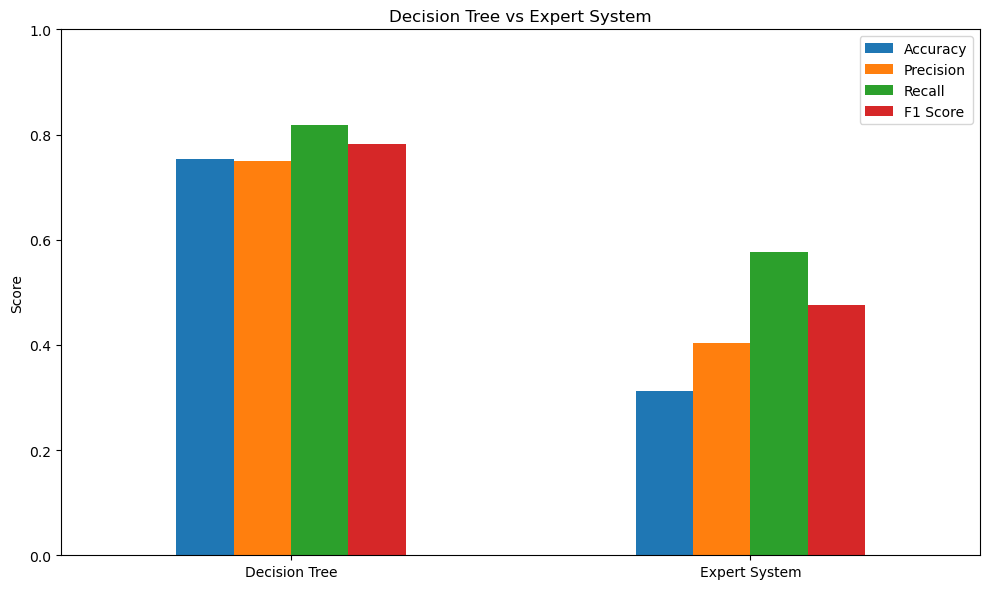

In [49]:
# VISUALIZATION

comparison_df.plot(kind="bar", figsize=(10, 6))

plt.title("Decision Tree vs Expert System")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


In [50]:
# EXPLAINABILITY SECTION


print(" EXPLAINABILITY ANALYSIS")


print("""
Decision Tree Model:
- Learns patterns automatically from data
- Captures complex relationships between features
- Higher prediction accuracy
- Less interpretable than rules

Expert System:
- Based on human-defined medical rules
- Fully interpretable and explainable
- Works without training data
- Limited flexibility compared to ML

FINAL CONCLUSION:
- Decision Tree is better for prediction performance
- Expert System is better for interpretability and reasoning
""")

 EXPLAINABILITY ANALYSIS

Decision Tree Model:
- Learns patterns automatically from data
- Captures complex relationships between features
- Higher prediction accuracy
- Less interpretable than rules

Expert System:
- Based on human-defined medical rules
- Fully interpretable and explainable
- Works without training data
- Limited flexibility compared to ML

FINAL CONCLUSION:
- Decision Tree is better for prediction performance
- Expert System is better for interpretability and reasoning

